In [240]:
from pathlib import Path

from ibkr_data.db import get_connection, count_5m_tickers
from ibkr_data.backtest import (
    get_market_days,
    fetch_tickers,
    run_backtest,
    generate_returns,
    make_title,
    generate_tearsheet,
    generate_fee_chart,
    FEE_PER_SHARE_TOTAL,
    MINIMUM_PER_ORDER,
)

conn = get_connection()


In [241]:
market_days = get_market_days()
print(f"{len(market_days)} market days from {market_days[0]} to {market_days[-1]}")


1255 market days from 2021-06-10 to 2026-06-09


In [242]:
tickers, ticker_params = fetch_tickers(conn, order_by="t.market_cap ASC", limit=100)
print(f"{len(tickers)} tickers")
print(tickers)


100 tickers
['EEM', 'FMC', 'CAG', 'CPB', 'MOS', 'POOL', 'ENPH', 'AOS', 'EMN', 'BLDR', 'NCLH', 'FDS', 'JKHY', 'HSIC', 'CRL', 'ARE', 'HUBS', 'BAX', 'AES', 'IT', 'DPZ', 'GDDY', 'FRT', 'PODD', 'ALLE', 'CPT', 'HII', 'BXP', 'CLX', 'HAS', 'ERIE', 'PNR', 'MGM', 'AVY', 'IVZ', 'GL', 'AIZ', 'PNW', 'DVA', 'ALGN', 'APA', 'MKC', 'EG', 'HRL', 'COO', 'LULU', 'GPC', 'CSGP', 'DOC', 'BALL', 'APTV', 'MAS', 'J', 'NWSA', 'GEN', 'GNRC', 'LDOS', 'DECK', 'BBY', 'NDSN', 'IEX', 'BEN', 'MAA', 'CF', 'NWS', 'HST', 'KIM', 'CDW', 'NVR', 'BR', 'GPN', 'INVH', 'AMCR', 'GIS', 'ALB', 'IP', 'LII', 'LNT', 'MRNA', 'EVRG', 'DD', 'FTV', 'IFF', 'ESS', 'BRO', 'AKAM', 'PKG', 'EFX', 'ENTG', 'LYB', 'INCY', 'FIS', 'LUV', 'CHTR', 'EXE', 'OMC', 'DLTR', 'EXPD', 'L', 'NI']


In [243]:
# IBKR Pro Tiered fees (US stocks, ≤ 300K shares/month)
commission_per_share = 0.0035    # IBKR base commission
exchange_fee = 0.0030            # Exchange pass-through (taking liquidity, blended)
clearing_fee = 0.0002            # NSCC/DTC clearing
finra_cat = 0.000003             # FINRA CAT
sec_fee_rate = 0.0000206         # SEC fee on sells only
minimum_per_order = 0.35
maximum_per_order_pct = 0.01     # 1% of trade value

def trade_cost(shares, price, sell=False):
    """IBKR Pro Tiered all-in cost for one side of a US stock trade."""
    per_share = commission_per_share + exchange_fee + clearing_fee + finra_cat
    fee = max(shares * per_share, minimum_per_order)
    fee = min(fee, shares * price * maximum_per_order_pct)
    if sell:
        fee += shares * price * sec_fee_rate  # SEC fee on sells
    return fee



In [244]:
slippage = 0.0001
risk_per_trade = 0.01
best_n_stocks = 5
atr_distance = 0.1
relative_volume_threshold = 2.0


In [245]:
result = run_backtest(
    conn,
    tickers=tickers,
    market_days=market_days,
    slippage=slippage,
    risk_per_trade=risk_per_trade,
    best_n_stocks=best_n_stocks,
    atr_distance=atr_distance,
    relative_volume_threshold=relative_volume_threshold,
)

print(f"{len(result['equity'])} days processed")
print(f"trades: {result['trade_count']}, fees: ${result['total_fees']:.2f}")


1255 days processed
trades: 1182, fees: $1125.35


In [246]:
returns = generate_returns(result["equity"])

n_total = count_5m_tickers(conn)
title = make_title(result["params"], len(tickers), n_total)

path = generate_tearsheet(returns, output_dir="backtests/multi", title=title)
print(f"Saved: {path}")


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

Saved: backtests/multi/019eae97-861d-70dc-b189-a7d42020c8ba.html


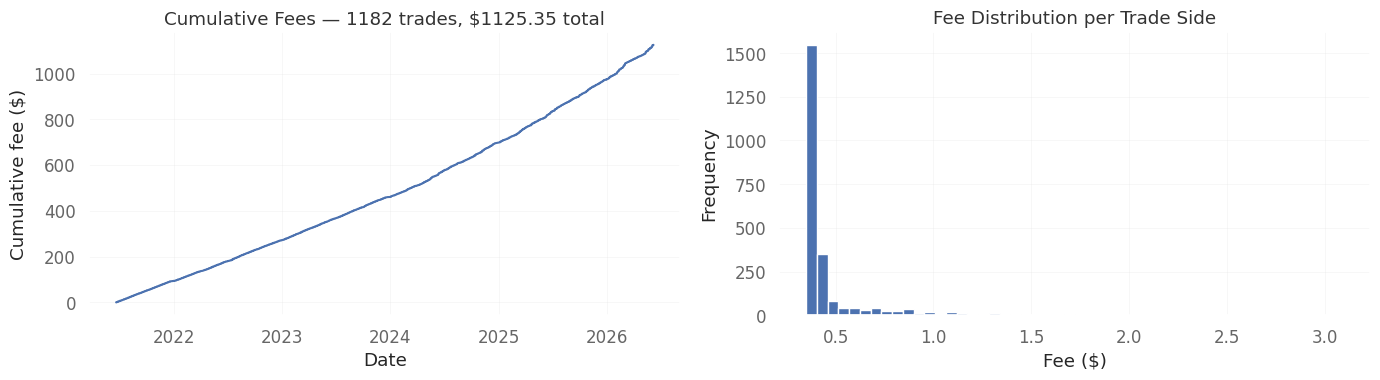

In [247]:
fig = generate_fee_chart(
    result["trade_fees"],
    result["trade_count"],
    result["total_fees"],
)
if fig is not None:
    import matplotlib.pyplot as plt
    plt.show()
else:
    print("No trades made")
